# 3. Линейные слои, функции активации и визуализация обучения

**Цель:** Реализовать полносвязные слои, изучить функции активации, построить классификатор и визуализировать обучение.

---

In [1]:
# Импорт библиотек: PyTorch, numpy, matplotlib, sklearn
import sys, os, math

import torch
import torch.nn as nn          # нейросетевые слои
import torch.nn.functional as F # функции активации и потерь
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons  # синтетический датасет

# Автовыбор устройства: CUDA > MPS > CPU (трансформеры требуют GPU)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")


## 3.1 Линейный слой (nn.Linear) изнутри

In [3]:
# Создаём полносвязный слой: 4 входа -> 3 выхода
linear = nn.Linear(in_features=4, out_features=3, bias=True)
# Веса хранятся в тензоре формы (out_features, in_features)
print(f"Weight shape: {linear.weight.shape}")  # (3, 4)
print(f"Bias shape:   {linear.bias.shape}")    # (3,)
print(f"Weight:\n{linear.weight.data}")
print(f"Bias: {linear.bias.data}")

# Пропускаем батч из 2 примеров через слой: y = x @ W^T + b
x = torch.randn(2, 4)
y = linear(x)
print(f"Input: {x.shape} -> Output: {y.shape}")
print(f"Output:\n{y}")

# Ручная реализация для проверки понимания
y_manual = x @ linear.weight.T + linear.bias
print(f"Manual output matches: {torch.allclose(y, y_manual)}")


Weight shape: torch.Size([3, 4])
Bias shape:   torch.Size([3])
Weight:
tensor([[ 0.2369,  0.3823, -0.3507,  0.0298],
        [ 0.2582,  0.2804, -0.1400, -0.4467],
        [-0.1970, -0.0584, -0.1464,  0.0584]])
Bias: tensor([0.0111, 0.0409, 0.4306])
Input: torch.Size([2, 4]) -> Output: torch.Size([2, 3])
Output:
tensor([[ 0.0992, -0.2531,  0.6550],
        [ 0.5020, -0.1447,  0.6927]], grad_fn=<AddmmBackward0>)
Manual output matches: True


## 3.2 Функции активации

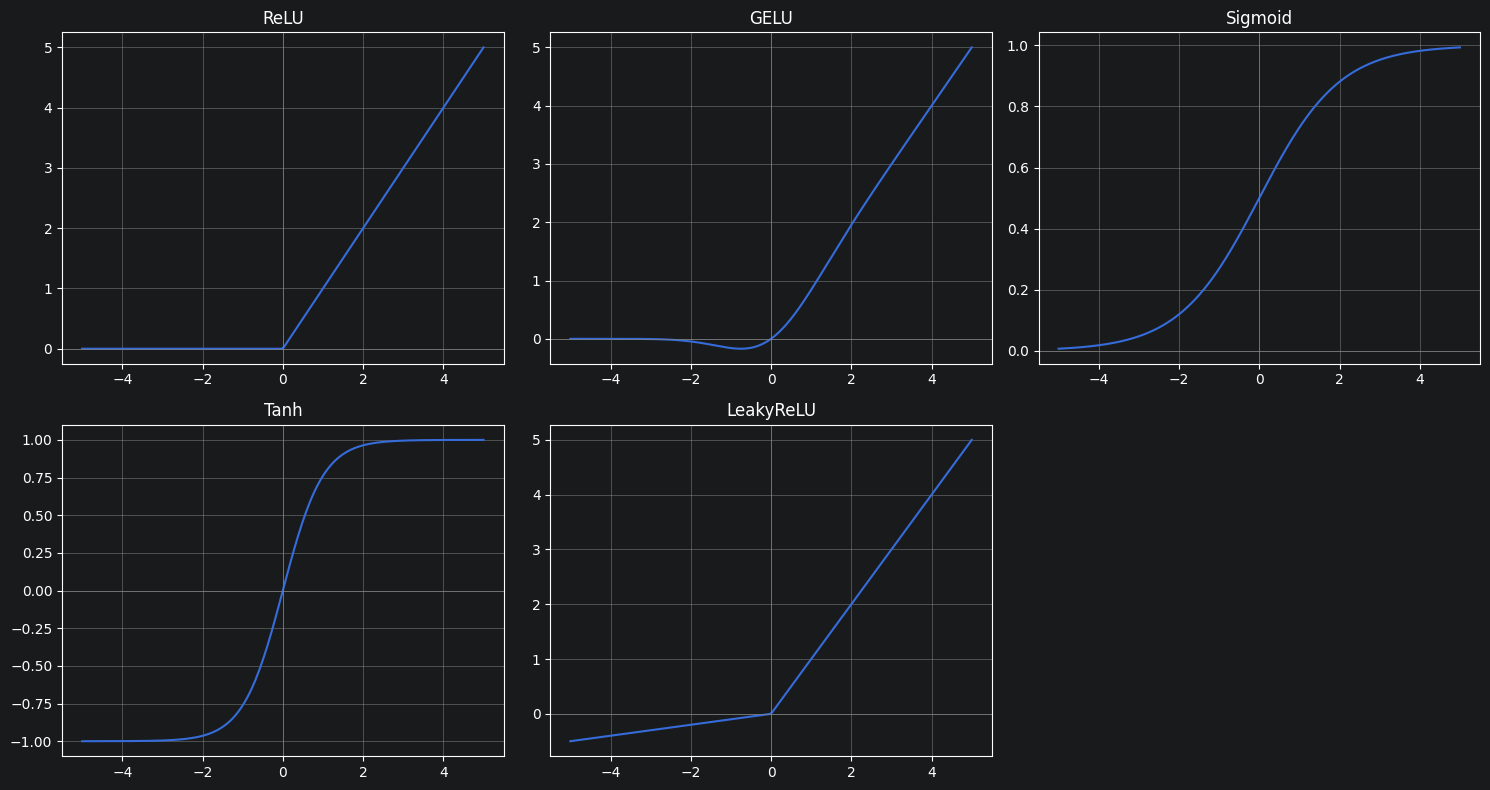

In [4]:
# Визуализируем функции активации на отрезке [-5, 5]
x = torch.linspace(-5, 5, 200)

activations = {
    "ReLU": F.relu(x),           # Rectified Linear Unit: max(0, x)
    "GELU": F.gelu(x),           # Gaussian Error Linear Unit (используется в трансформерах)
    "Sigmoid": torch.sigmoid(x), # сигмоида: 1/(1+e^{-x})
    "Tanh": torch.tanh(x),       # гиперболический тангенс
    "LeakyReLU": F.leaky_relu(x, 0.1),  # ReLU с наклоном для x < 0
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (name, y) in zip(axes.flat, activations.items()):
    ax.plot(x, y)
    ax.set_title(name)
    ax.grid(True)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()


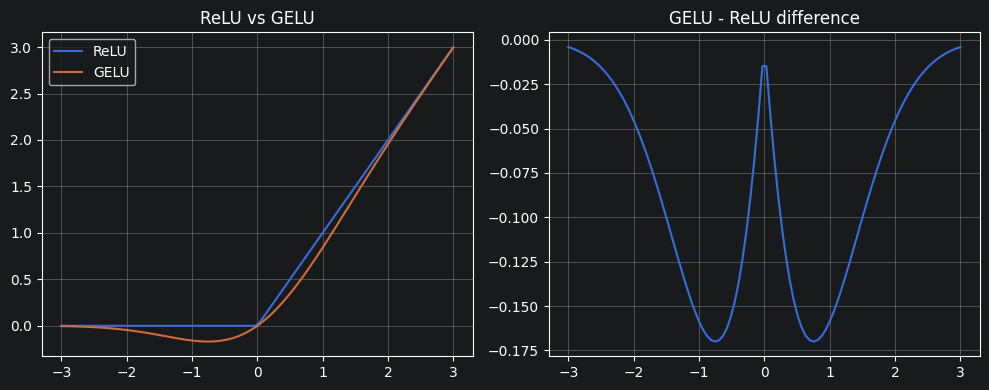

In [5]:
# Сравнение ReLU и GELU: чем отличается гладкая аппроксимация?
# GELU — гладкая версия ReLU, используется в BERT, GPT и других трансформерах
x = torch.linspace(-3, 3, 100)
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(x, F.relu(x), label='ReLU')
plt.plot(x, F.gelu(x), label='GELU')
plt.legend()
plt.grid(True)
plt.title('ReLU vs GELU')

# Разница: GELU имеет ненулевые значения при x < 0, что улучшает градиенты
plt.subplot(1, 2, 2)
plt.plot(x, F.gelu(x) - F.relu(x))
plt.title('GELU - ReLU difference')
plt.grid(True)
plt.tight_layout()
plt.show()


## 3.3 Классификатор на синтетических данных

Dataset: X torch.Size([500, 2]), y torch.Size([500])
Classes: [0, 1]


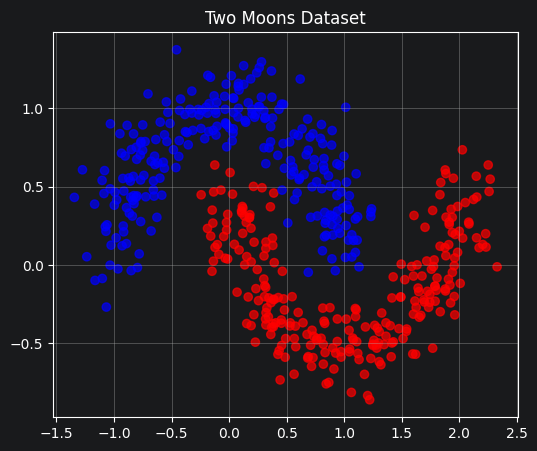

In [6]:
# Генерируем синтетический датасет «Две луны» для бинарной классификации
X_np, y_np = make_moons(n_samples=500, noise=0.15, random_state=42)
X = torch.tensor(X_np, dtype=torch.float32)  # конвертируем numpy -> PyTorch
y = torch.tensor(y_np, dtype=torch.long)

print(f"Dataset: X {X.shape}, y {y.shape}")
print(f"Classes: {y.unique().tolist()}")

# Визуализируем: два класса в виде полумесяцев
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.7)
plt.title('Two Moons Dataset')
plt.grid(True)
plt.show()


In [25]:
# Определяем архитектуру: 3 полносвязных слоя с ReLU
class SimpleClassifier(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=32, num_classes=2):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)   # 2 -> 32
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)   # 32 -> 32
        self.fc3 = nn.Linear(hidden_dim, num_classes)  # 32 -> 2
        
    def forward(self, x):
        x = F.relu(self.fc1(x))  # первый скрытый слой + ReLU
        x = F.relu(self.fc2(x))  # второй скрытый слой + ReLU
        x = self.fc3(x)          # выходной слой (без активации — CrossEntropyLoss сама применит softmax)
        return x

# Инициализируем модель, функцию потерь и оптимизатор Adam
model = SimpleClassifier().to(device)
criterion = nn.CrossEntropyLoss()  # сочетание LogSoftmax + NLLLoss
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Переносим данные на выбранное устройство (GPU/CPU)
X, y = X.to(device), y.to(device)


In [26]:
# Цикл обучения: forward -> loss -> backward -> optimizer.step
losses = []
accs = []
n_epochs = 200

for epoch in range(n_epochs):
    logits = model(X)          # forward pass
    loss = criterion(logits, y)  # вычисляем loss
    
    optimizer.zero_grad()  # обнуляем градиенты
    loss.backward()        # обратное распространение
    optimizer.step()       # шаг оптимизации
    
    losses.append(loss.item())
    acc = (logits.argmax(1) == y).float().mean().item()
    accs.append(acc)


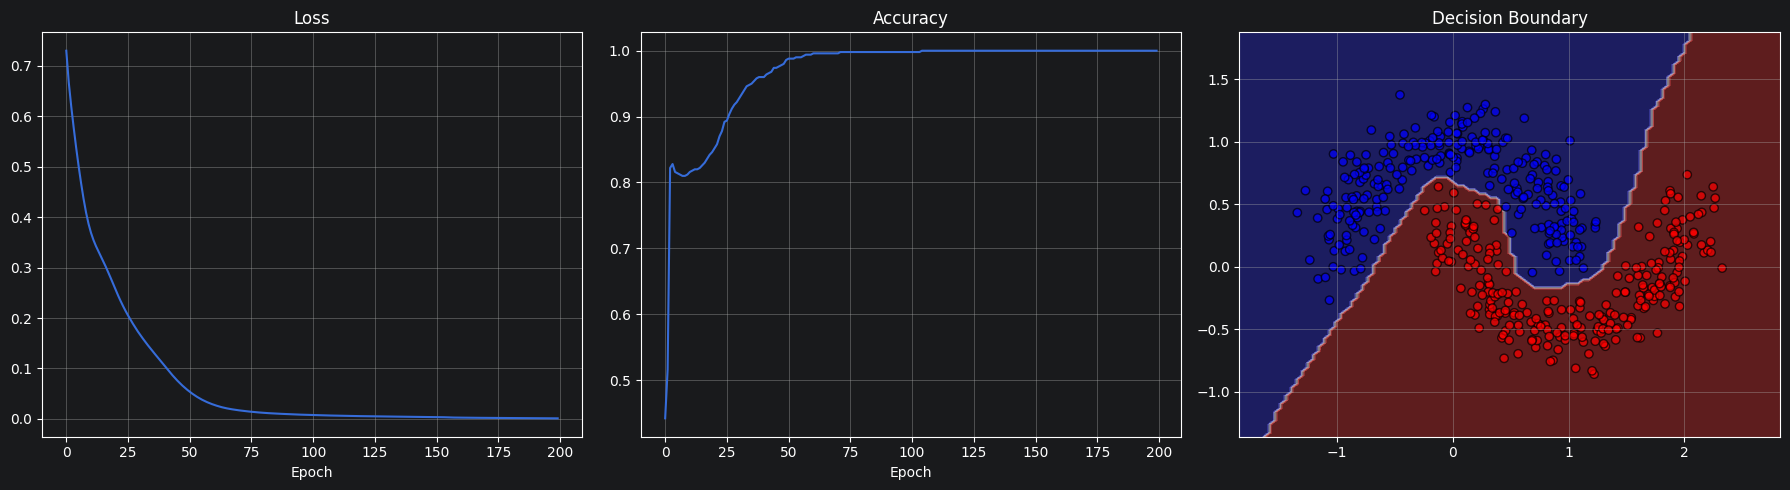

In [27]:
# Визуализация: кривая потерь, точность, граница решения
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Кривая потерь (loss)
axes[0].plot(losses)
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid(True)

# Кривая точности (accuracy)
axes[1].plot(accs)
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].grid(True)

# Граница решения: предсказания модели на всей плоскости
x_min, x_max = X[:, 0].min().item() - 0.5, X[:, 0].max().item() + 0.5
y_min, y_max = X[:, 1].min().item() - 0.5, X[:, 1].max().item() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32, device=device)
with torch.no_grad():
    Z = model(grid).argmax(1).cpu().numpy().reshape(xx.shape)
axes[2].contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
axes[2].scatter(X[:, 0].cpu(), X[:, 1].cpu(), c=y.cpu(), cmap='bwr', edgecolors='k', alpha=0.7)
axes[2].set_title('Decision Boundary')
axes[2].grid(True)

plt.tight_layout()
plt.show()


## 3.4 Сравнение активаций: ReLU vs GELU в классификаторе

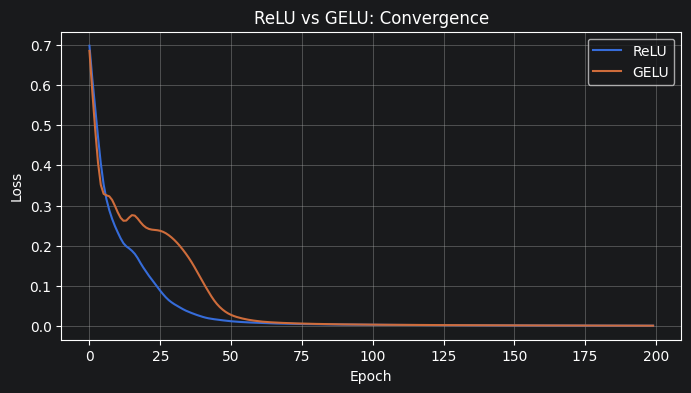

In [28]:
# Сравниваем ReLU и GELU: обучаем два классификатора и сравниваем сходимость
class ComparativeClassifier(nn.Module):
    def __init__(self, activation=F.relu, hidden_dim=64):
        super().__init__()
        self.activation = activation
        self.fc1 = nn.Linear(2, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, 2)
        
    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        return self.fc3(x)

results = {}
for name, act in [("ReLU", F.relu), ("GELU", F.gelu)]:
    m = ComparativeClassifier(activation=act).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=0.01)
    losses = []
    for _ in range(200):
        l = nn.CrossEntropyLoss()(m(X), y)
        opt.zero_grad()
        l.backward()
        opt.step()
        losses.append(l.item())
    results[name] = losses

plt.figure(figsize=(8, 4))
for name, losses in results.items():
    plt.plot(losses, label=name)
plt.legend()
plt.title('ReLU vs GELU: Convergence')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()


In [29]:
# Подводим итог: линейные слои и функции активации
print("=== Linear layers and activations complete ===")
print("Topics covered:")
print("  - nn.Linear internals (weight, bias, manual computation)")
print("  - Activation functions: ReLU, GELU, Sigmoid, Tanh, LeakyReLU")
print("  - GELU vs ReLU: why GELU is preferred in transformers")
print("  - Binary classifier on two moons dataset")
print("  - Training loop, loss curves, accuracy")
print("  - Decision boundary visualization")
print("  - Comparative convergence: ReLU vs GELU")


=== Linear layers and activations complete ===
Topics covered:
  - nn.Linear internals (weight, bias, manual computation)
  - Activation functions: ReLU, GELU, Sigmoid, Tanh, LeakyReLU
  - GELU vs ReLU: why GELU is preferred in transformers
  - Binary classifier on two moons dataset
  - Training loop, loss curves, accuracy
  - Decision boundary visualization
  - Comparative convergence: ReLU vs GELU
